In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf 
from tensorflow import keras 
from tensorflow.keras import layers 


Task - 1

In [2]:
#Load the dataset Amazon fruit 
import os
train_dir = "E:\\6CS012\\Week5\\FruitinAmazon\\train"
test_dir  = "E:\\6CS012\\Week5\\FruitinAmazon\\test"

# def load_images_from_folder(folder):
#     images, labels = [], []
#     class_names = sorted(os.listdir(folder))
#     class_map = {name: i for i, name in enumerate(class_names)}

#     for class_name in class_names:
#         class_path = os.path.join(folder, class_name)
#         label = class_map[class_name]
#         for filename in os.listdir(class_path):
#             img_path = os.path.join(class_path, filename)
#             # img = Image.open(img_path).convert("L").resize((28, 28))
#             img = Image.open(img_path).convert("RGB").resize((128,128))# Convert to RGB and resize
#             img = np.array(img) / 255.0                     # normalize to [0,1]
#             images.append(img)
#             labels.append(label)
#     return np.array(images), np.array(labels)

# x_train, y_train = load_images_from_folder(train_dir)
# x_test,  y_test  = load_images_from_folder(test_dir)

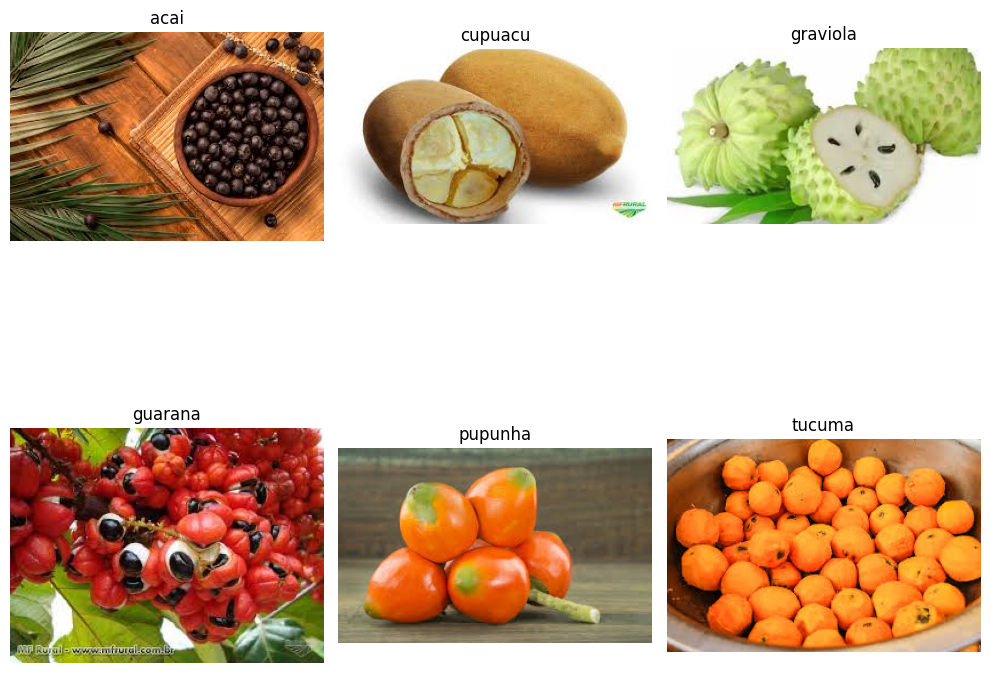

In [3]:
import math

classes = sorted(os.listdir(train_dir))
n = len(classes)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(10, 5 * rows))
axes = axes.flatten()

for i, class_name in enumerate(classes):
    img_path = os.path.join(train_dir, class_name, os.listdir(os.path.join(train_dir, class_name))[0])
    img = Image.open(img_path)

    axes[i].imshow(img)
    axes[i].set_title(class_name)
    axes[i].axis("off")

# remove empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [4]:
#Checking if the images are valid in train directory 
for class_ in classes: 
    class_path = os.path.join(train_dir, class_)
    for image in os.listdir(class_path):
        img_path = os.path.join(class_path , image)
        try: 
            img = Image.open(img_path)
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
    print(f"Successfully loaded all images in {class_} class")
    print(f"Total images in {class_} class: {len(os.listdir(class_path))}")

Successfully loaded all images in acai class
Total images in acai class: 15
Successfully loaded all images in cupuacu class
Total images in cupuacu class: 15
Successfully loaded all images in graviola class
Total images in graviola class: 15
Successfully loaded all images in guarana class
Total images in guarana class: 15
Successfully loaded all images in pupunha class
Total images in pupunha class: 15
Successfully loaded all images in tucuma class
Total images in tucuma class: 15


Task 2

In [5]:
img_height, img_width = 128, 128
batch_size = 32
validation_split = 0.3
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0,1]
train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size, 
    labels = "inferred",
    interpolation = "nearest",
    label_mode = "categorical"
)
train_ds = train_ds.map(lambda x, y: (rescale(x), y)) # Normalize pixel values to [0,1]
val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="validation",
    seed = 123, 
    image_size=(img_height, img_width),
    batch_size=batch_size,
    labels = "inferred",
    interpolation = "nearest",
    label_mode = "categorical"
)   
# val_ds = val_ds.map(lambda x, y: (rescale(x), y)) # Normalize pixel values to [0,1]

Found 90 files belonging to 6 classes.
Using 63 files for training.
Found 90 files belonging to 6 classes.
Using 27 files for validation.


In [6]:
data_augmentation_layers = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

def data_augmentation(images):
  for layer in data_augmentation_layers:
    images = layer(images)
    return images
  
# 

Implement a CNN model

In [7]:
model = keras.Sequential([
    layers.Lambda(data_augmentation_layers, input_shape=(128, 128, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.BatchNormalization(),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(),
    
    layers.BatchNormalization(),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),  

    layers.Dense(64, activation='relu'),
    # layers.Dropout(0.5),            # stronger regularization
    layers.Dense(len(classes), activation='softmax')
])

c:\Users\rohit\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,790 (401.52 KB)

 Trainable params: 102,342 (399.77 KB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
compile_args = {
    "optimizer": "adam",
    
    "loss": "categorical_crossentropy",
    "metrics": ["accuracy", "precision", "recall", "f1_score"]
}
model.compile(**compile_args)

In [21]:
callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4),
]
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[callbacks, lr_scheduler],
    batch_size=16
)



Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 1.0000 - loss: 0.0182 - val_accuracy: 0.6296 - val_loss: 26.8805 - learning_rate: 0.0010
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 1.0000 - loss: 0.0260 - val_accuracy: 0.6296 - val_loss: 26.9962 - learning_rate: 0.0010
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 1.0000 - loss: 0.0199 - val_accuracy: 0.6296 - val_loss: 27.1644 - learning_rate: 0.0010
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 1.0000 - loss: 0.0184 - val_accuracy: 0.6296 - val_loss: 27.3229 - learning_rate: 0.0010
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 1.0000 - loss: 0.0143 - val_accuracy: 0.6296 - val_loss: 27.3527 - learning_rate: 2.0000e-04


In [22]:
model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.6296 - loss: 27.3527


[27.352664947509766, 0.6296296119689941]

In [23]:
model.save("fruit_CNN.h5")

In [24]:
#Predictions 
pred_probs = model.predict(val_ds)
pred_labels = np.argmax(pred_probs, axis=1)

#Actual 
actual_labels = np.concatenate([y for x, y in val_ds], axis=0)
actual_labels = np.argmax(actual_labels, axis=1)

# Convert to class names
pred_names = [classes[i] for i in pred_labels]
true_names = [classes[i] for i in actual_labels]

# Print
print("Predictions:", pred_names)
print("Actual:", true_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step
Predictions: ['cupuacu', 'acai', 'guarana', 'tucuma', 'acai', 'acai', 'tucuma', 'tucuma', 'acai', 'graviola', 'graviola', 'pupunha', 'cupuacu', 'graviola', 'guarana', 'acai', 'graviola', 'acai', 'cupuacu', 'guarana', 'tucuma', 'tucuma', 'graviola', 'guarana', 'guarana', 'guarana', 'cupuacu']
Actual: ['guarana', 'pupunha', 'graviola', 'graviola', 'cupuacu', 'guarana', 'tucuma', 'pupunha', 'guarana', 'guarana', 'pupunha', 'tucuma', 'tucuma', 'acai', 'acai', 'guarana', 'guarana', 'pupunha', 'pupunha', 'cupuacu', 'tucuma', 'guarana', 'acai', 'graviola', 'cupuacu', 'graviola', 'graviola']


In [25]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(actual_labels, pred_labels, target_names=classes))



              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       0.00      0.00      0.00         3
    graviola       0.00      0.00      0.00         5
     guarana       0.00      0.00      0.00         7
     pupunha       0.00      0.00      0.00         5
      tucuma       0.40      0.50      0.44         4

    accuracy                           0.07        27
   macro avg       0.07      0.08      0.07        27
weighted avg       0.06      0.07      0.07        27



In [26]:
print(confusion_matrix(actual_labels, pred_labels))

[[0 0 2 1 0 0]
 [1 0 0 2 0 0]
 [0 1 0 3 0 1]
 [3 1 2 0 0 1]
 [2 1 1 0 0 1]
 [0 1 0 0 1 2]]


Task 2 (Image classification via fine-tuning with VGG16)

In [27]:
from tensorflow.keras.applications import VGG16
# Load the VGG16 model pre-trained on ImageNet, without the top classification layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

In [28]:
# Freeze the layers of the base model
for layer in base_model.layers:
 layer.trainable = False

In [29]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
# Add custom layers on top of the pre-trained model
x = base_model.output
x = GlobalAveragePooling2D()(x) # Reduces dimensions (height, width) to a single vector per image
x = Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x) # Fully connected layer with 1024 neurons
x = Dense(6, activation='softmax')(x)

In [30]:
from tensorflow.keras.models import Model
# Create the final model
model = Model(inputs=base_model.input, outputs=x)

In [32]:
from tensorflow.keras.optimizers import Adam
callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10),
]
# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_ds, batch_size=16, validation_data=val_ds, epochs=250, callbacks=callbacks)

Epoch 1/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.7778 - loss: 0.9279 - val_accuracy: 0.2593 - val_loss: 13.0633
Epoch 2/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.8730 - loss: 0.7734 - val_accuracy: 0.2963 - val_loss: 11.9856
Epoch 3/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.8254 - loss: 0.8150 - val_accuracy: 0.3333 - val_loss: 11.9523
Epoch 4/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.8889 - loss: 0.7320 - val_accuracy: 0.3333 - val_loss: 12.3627
Epoch 5/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.9206 - loss: 0.6912 - val_accuracy: 0.3333 - val_loss: 12.3807
Epoch 6/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.8571 - loss: 0.6873 - val_accuracy: 0.3333 - val_loss: 12.7464
Epoch 7/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.8889 - loss: 0.6403 - val_accuracy: 0.3333 - val_loss: 12.8591
Epoch 8/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.8889 - loss: 0.5857 - val_accuracy: 0.3333 - val_loss: 13.5117


In [33]:
model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.3704 - loss: 15.1664


[15.166447639465332, 0.37037035822868347]

In [ ]:
model.save("fruit_CNN_finetuned.h5")

In [ ]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         6,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,309,076 (62.21 MB)

 Trainable params: 531,462 (2.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 1,062,926 (4.05 MB)

In [ ]:
from tensorflow.keras.applications import VGG16

model_ = VGG16(weights='imagenet')
model_.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 33s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)